In [1]:
import sys
from pathlib import Path

current = Path.cwd()
project_root = current.parent.parent
sys.path.append(str(project_root))

from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()

In [2]:
from data.linear import LinearTaskGenerator
from models.linear_attention import SingleLayerLSA, SingleLayerSelfAttention
from experiments.single_layer.train import train_ICL_model
from experiments.single_layer.test import compare_SignelLSA_matrices
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim

In [3]:
NX = 10
NY = 1

N = 10
W_STD = 1.0
X_RANGE = (-1, 1)

N_STEPS = 1000
BATCH_SIZE = 2048
LR = 0.001

ETA_VALUES = np.logspace(-3, 2, 100)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
generator = LinearTaskGenerator(nx=NX, ny=NY, x_range=X_RANGE, noise=None, w_std=W_STD)
model = SingleLayerLSA(nx=NX, ny=NY)
optimizer = optim.AdamW(model.parameters(), lr=LR)
device

'cuda'

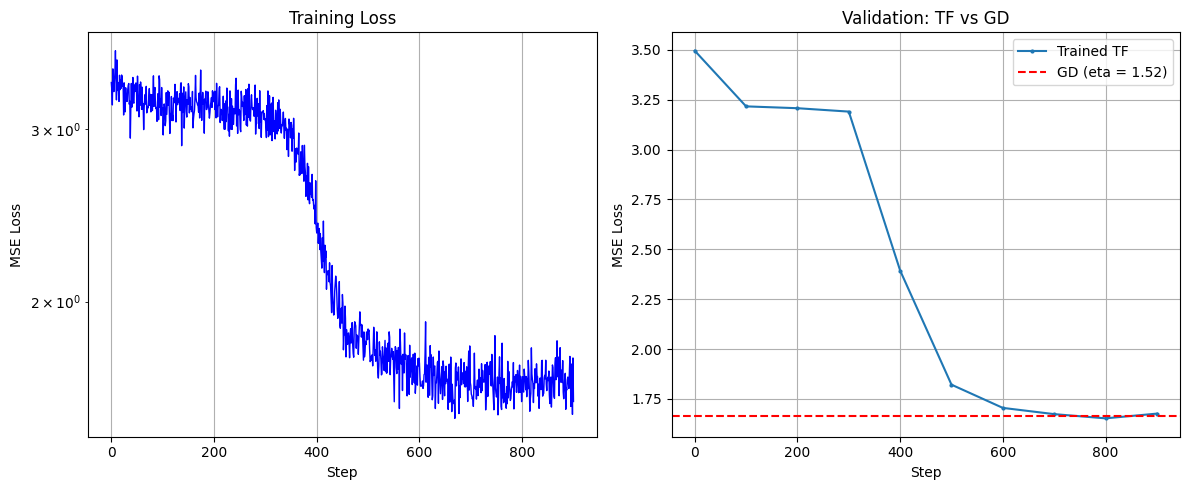

Training: 100%|██████████| 1000/1000 [01:27<00:00, 11.40it/s, gd_val=1.6623, tf_val=1.6765, train_loss=1.58]


In [7]:
model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)

In [3]:
NX = 10
NY = 1

N = 10
W_STD = 1.0
X_RANGE = (-1, 1)

N_STEPS = 2000
BATCH_SIZE = 2048
LR = 0.001

ETA_VALUES = np.logspace(-3, 2, 100)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
generator = LinearTaskGenerator(nx=NX, ny=NY, x_range=X_RANGE, noise=None, w_std=W_STD)
model = SingleLayerSelfAttention(nx=NX, ny=NY)
optimizer = optim.AdamW(model.parameters(), lr=LR)
device

'cuda'

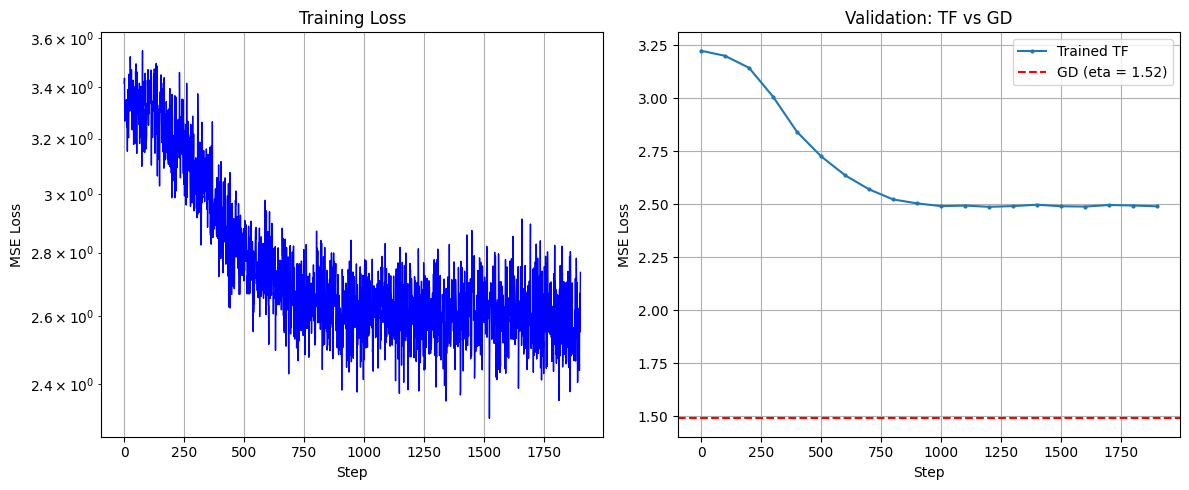

Training: 100%|██████████| 2000/2000 [02:52<00:00, 11.62it/s, gd_val=1.4895, tf_val=2.4902, train_loss=2.74]


In [4]:
model, losses, tf_val, gd_val, best_eta = train_ICL_model(
    model=model,
    task_generator=generator,
    optimizer=optimizer,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    N=N,
    device=device,
    test_interval=100,
    val_tasks=1000,
    eta_values=ETA_VALUES
)